# ECG Heartbeat Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [2]:
normal = pd.read_csv("../ECG Dataset/ptbdb_normal.csv", header = None)
abnormal = pd.read_csv("../ECG Dataset/ptbdb_abnormal.csv", header = None)

In [3]:
dataset = pd.concat([normal, abnormal], ignore_index=True)
dataset

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.900324,0.358590,0.051459,0.046596,0.126823,0.133306,0.119125,0.110616,0.113047,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.794681,0.375387,0.116883,0.000000,0.171923,0.283859,0.293754,0.325912,0.345083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.909029,0.791482,0.423169,0.186712,0.000000,0.007836,0.063032,0.077002,0.074957,0.077342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.478893,0.056760,0.064176,0.081289,0.072732,0.055619,0.048774,0.054478,0.041643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,0.867238,0.201360,0.099349,0.141336,0.120934,0.108516,0.096393,0.093436,0.100828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14547,0.981409,1.000000,0.559171,0.287093,0.196639,0.204862,0.215946,0.243833,0.242760,0.250268,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14548,0.906250,0.922379,0.878024,0.810484,0.712702,0.667339,0.608871,0.527218,0.480847,0.442540,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14549,1.000000,0.867971,0.674122,0.470332,0.296987,0.169307,0.077664,0.081392,0.074868,0.089779,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14550,1.000000,0.984672,0.658888,0.556394,0.446809,0.395790,0.315260,0.276367,0.261039,0.258522,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Check if any value is Null

In [4]:
print(dataset.isnull().values.any())
print(dataset.isna().values.any())

False
False


In [5]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [6]:
print(y.value_counts())

187
1.0    10506
0.0     4046
Name: count, dtype: int64


## Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1) # seeding the dataset with '1'
X_train, X_test, y_train, y_test

(            0         1         2         3         4         5         6    \
 2313   0.920422  1.000000  0.479288  0.228561  0.031613  0.065044  0.129724   
 10009  0.897787  0.652266  0.074816  0.037935  0.030558  0.134879  0.295047   
 4960   1.000000  0.968713  0.634748  0.539227  0.429960  0.374259  0.280161   
 11757  0.902920  0.991318  0.894238  0.826361  0.743489  0.676401  0.631413   
 6112   1.000000  0.669126  0.339891  0.181148  0.152186  0.137978  0.103005   
 ...         ...       ...       ...       ...       ...       ...       ...   
 905    1.000000  0.919740  0.630803  0.315401  0.116269  0.007809  0.077223   
 5192   1.000000  0.595851  0.351912  0.158210  0.134466  0.107473  0.076731   
 12172  0.930952  0.764881  0.376190  0.250595  0.263095  0.197024  0.144048   
 235    1.000000  0.929658  0.372243  0.071483  0.077947  0.146008  0.148289   
 13349  1.000000  0.502685  0.042965  0.192266  0.245972  0.255639  0.191192   
 
             7         8         9    

In [8]:
print(y_train.value_counts())
print(y_test.value_counts())

187
1.0    8408
0.0    3233
Name: count, dtype: int64
187
1.0    2098
0.0     813
Name: count, dtype: int64


## Feature Scaling

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)   # Learn min/max from training data
X_test = scaler.transform(X_test)         # Use the same min/max for test data

In [10]:
X_train, X_test

(array([[0.78822705, 1.        , 0.4792878 , ..., 0.        , 0.        ,
         0.        ],
        [0.72799277, 0.65226555, 0.07481559, ..., 0.        , 0.        ,
         0.        ],
        [1.        , 0.96871299, 0.63474756, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.81625153, 0.76488096, 0.37619048, ..., 0.        , 0.        ,
         0.        ],
        [1.        , 0.92965782, 0.37224334, ..., 0.        , 0.        ,
         0.        ],
        [1.        , 0.50268531, 0.04296456, ..., 0.        , 0.        ,
         0.        ]], shape=(11641, 187)),
 array([[1.        , 0.91621327, 0.8726877 , ..., 0.        , 0.        ,
         0.        ],
        [0.85200551, 0.80816329, 0.39693877, ..., 0.        , 0.        ,
         0.        ],
        [0.96299959, 0.10160428, 0.12513369, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.83885171, 0.57190919, 0.08284272, ..., 0.        , 0.        ,
         0.   

## Know the `class_weight`

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.float64(0.0): np.float64(1.8003402412619858), np.float64(1.0): np.float64(0.6922573739295909)}


## Reshape the data for LSTM

In [12]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [13]:
print(X_train.shape)
print(X_test.shape)

(11641, 187, 1)
(2911, 187, 1)


## Build LSTM

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

I0000 00:00:1784080216.099416    7057 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam

model = Sequential()

# First LSTM Layer
model.add(LSTM(128, return_sequences=True, input_shape=(187, 1)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Second LSTM Layer
model.add(LSTM(64, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Third LSTM Layer
model.add(LSTM(32))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Dense Layers
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation="sigmoid"))

# Compile
optimizer = Adam(learning_rate=0.0005)

model.load_weights("lstm_weights.weights.h5")

W0000 00:00:1784080220.215353    7057 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/programmer/PyTorch Project/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=[
        "accuracy"
    ]
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 187, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 187, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 187, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,505 (521.50 KB)

 Trainable params: 133,057 (519.75 KB)

 Non-trainable params: 448 (1.75 KB)

## Train the model

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 67s 173ms/step - accuracy: 0.6845 - loss: 0.6256 - val_accuracy: 0.7235 - val_loss: 0.5701
Epoch 2/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 65s 178ms/step - accuracy: 0.7212 - loss: 0.5616 - val_accuracy: 0.6956 - val_loss: 0.5871
Epoch 3/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 65s 178ms/step - accuracy: 0.7239 - loss: 0.5273 - val_accuracy: 0.7331 - val_loss: 0.5012
Epoch 4/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 66s 181ms/step - accuracy: 0.7320 - loss: 0.5056 - val_accuracy: 0.7351 - val_loss: 0.5451
Epoch 5/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 65s 178ms/step - accuracy: 0.7600 - loss: 0.4806 - val_accuracy: 0.7290 - val_loss: 0.5171
Epoch 6/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 65s 178ms/step - accuracy: 0.7678 - loss: 0.4631 - val_accuracy: 0.7059 - val_loss: 0.5679
Epoch 7/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 66s 180ms/step - accuracy: 0.7869 - loss: 0.4515 - val_accuracy: 0.8066 - val_loss: 0.4234
Epoch 8/50
364/364 ━━━━━━━━━━━━━━━━━━━━ 65s 179ms/step - accuracy: 0.8104 - loss: 0

In [31]:
def predict_ecg(sample):
    """
    sample shape should be (1, 187, 1)
    """

    probability = float(model.predict(sample, verbose=0)[0][0])

    if probability >= 0.5:
        label = "Abnormal"
        confidence = probability
    else:
        label = "Normal"
        confidence = 1 - probability

    return {
        "label": label,
        "confidence": round(confidence * 100, 2),
        # "probability": {
        #     "normal": round((1 - probability) * 100, 2),
        #     "abnormal": round(probability * 100, 2)
        # }
    }

## Classification Report

In [16]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
y_pred = y_pred.ravel()

print(classification_report(y_test, y_pred))

91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step
              precision    recall  f1-score   support

         0.0       0.95      0.90      0.93       813
         1.0       0.96      0.98      0.97      2098

    accuracy                           0.96      2911
   macro avg       0.96      0.94      0.95      2911
weighted avg       0.96      0.96      0.96      2911



In [17]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 733   80]
 [  35 2063]]


In [ ]:
# model.save_weights("lstm_weights.weights.h5")

## Integrating SHAP

In [18]:
import shap

background = X_train[np.random.choice(
    X_train.shape[0],
    100,
    replace=False
)]

explainer = shap.GradientExplainer(
    model,
    background
)

In [34]:
sample = X_test[45:46]

In [35]:
probability = model.predict(sample, verbose=0)[0][0]

prediction = "Abnormal" if probability >= 0.5 else "Normal"

confidence = probability if prediction == "Abnormal" else 1 - probability

In [36]:
shap_values = explainer.shap_values(sample)

In [37]:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

In [38]:
importance = np.abs(shap_values[0]).reshape(-1)
print(importance.shape)

(187,)


In [39]:
threshold = np.percentile(
    importance,
    95
)

important_timesteps = np.where(
    importance >= threshold
)[0]

In [40]:
print(important_timesteps)

[ 92 102 103 107 123 124 125 126 127 128]


In [41]:
regions = []

start = important_timesteps[0]
end = start

for t in important_timesteps[1:]:

    if t == end + 1:

        end = t

    else:

        regions.append({
            "start": int(start),
            "end": int(end),
            "mean_importance": float(
                importance[start:end+1].mean()
            )
        })

        start = t
        end = t

regions.append({
    "start": int(start),
    "end": int(end),
    "mean_importance": float(
        importance[start:end+1].mean()
    )
})

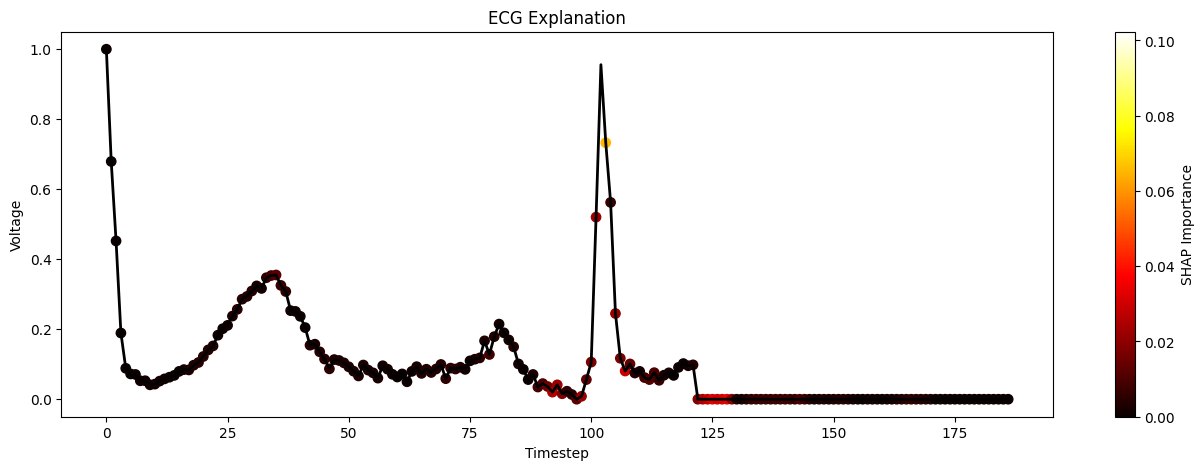

In [42]:
plt.figure(figsize=(16,5))

plt.plot(
    sample[0,:,0],
    color="black",
    linewidth=2
)

plt.scatter(
    np.arange(187),
    sample[0,:,0],
    c=importance,
    cmap="hot",
    s=45
)

plt.colorbar(label="SHAP Importance")

plt.title("ECG Explanation")

plt.xlabel("Timestep")

plt.ylabel("Voltage")

plt.show()

In [32]:
def predict_ecg(sample, top_percent=95):
    """
    sample shape -> (1, 187, 1)
    """

    # -------------------------
    # Prediction
    # -------------------------
    probability = float(model.predict(sample, verbose=0)[0][0])

    if probability >= 0.5:
        label = "Abnormal"
        confidence = probability
    else:
        label = "Normal"
        confidence = 1 - probability

    # -------------------------
    # SHAP Explanation
    # -------------------------
    shap_values = explainer.shap_values(sample)

    # Handle different SHAP versions
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    importance = np.abs(shap_values[0]).reshape(-1)

    # -------------------------
    # Select important timesteps
    # -------------------------
    threshold = np.percentile(importance, top_percent)

    important_idx = np.where(importance >= threshold)[0]

    # -------------------------
    # Create JSON for each point
    # -------------------------
    important_points = []

    for idx in important_idx:
        important_points.append({
            "timestep": int(idx),
            "importance": round(float(importance[idx]), 6),
            "ecg_value": round(float(sample[0, idx, 0]), 6)
        })

    # -------------------------
    # Return everything
    # -------------------------
    return {
        "label": label,
        "confidence": round(confidence * 100, 2),
        "important_points": important_points
    }

In [33]:
sample = X_test[29:30]
print(predict_ecg(sample))

/home/programmer/PyTorch Project/myenv/lib/python3.12/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 187, 1))']
  warnings.warn(msg)


{'label': 'Normal', 'confidence': 99.05, 'important_points': [{'timestep': 33, 'importance': 0.027723, 'ecg_value': 0.256707}, {'timestep': 84, 'importance': 0.043795, 'ecg_value': 0.068255}, {'timestep': 85, 'importance': 0.029649, 'ecg_value': 0.067182}, {'timestep': 103, 'importance': 0.027586, 'ecg_value': 0.062889}, {'timestep': 104, 'importance': 0.02882, 'ecg_value': 0.063533}, {'timestep': 119, 'importance': 0.028511, 'ecg_value': 0.060957}, {'timestep': 130, 'importance': 0.097247, 'ecg_value': 0.510195}, {'timestep': 131, 'importance': 0.262193, 'ecg_value': 0.954497}, {'timestep': 132, 'importance': 0.216043, 'ecg_value': 0.789654}, {'timestep': 133, 'importance': 0.037523, 'ecg_value': 0.257781}]}
